<a href="https://colab.research.google.com/github/Zukap/TalentoTech/blob/main/train_a_neural_network_using_different_libraries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

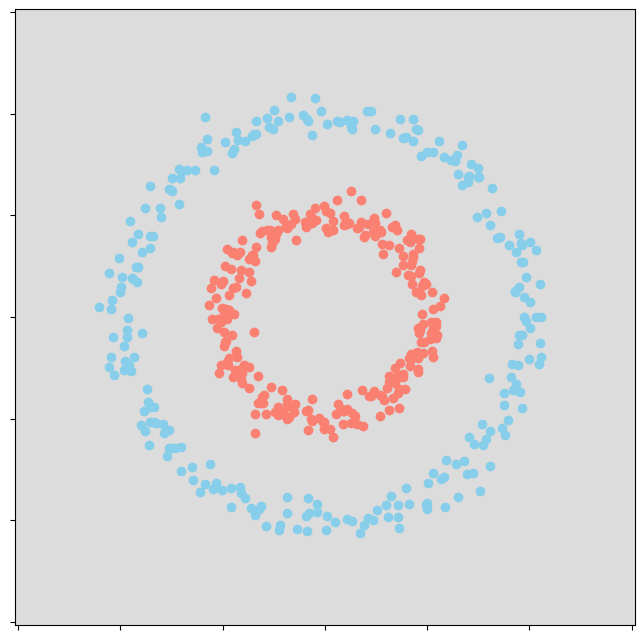

In [ ]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

X, Y = make_circles(n_samples=500, factor=0.5, noise=0.05)

res = 100

_x0 = np.linspace(-1.5, 1.5, res)
_x1 = np.linspace(-1.5, 1.5, res)

_pX = np.array(np.meshgrid(_x0, _x1)).T.reshape(-1, 2)

_pY = np.zeros((res, res)) + 0.5

plt.figure(figsize=(8, 8))
plt.pcolormesh(_x0, _x1, _pY, cmap="coolwarm",vmin=0, vmax=1)

plt.scatter(X[Y == 0,0], X[Y == 0,1], c="skyblue")
plt.scatter(X[Y == 1,0], X[Y == 1,1], c="Salmon")

plt.tick_params(labelbottom=False, labelleft=False)

Step 0 / 1000 - Loss = 0.16140462 - Acc = 0.756
Step 25 / 1000 - Loss = 0.06180026 - Acc = 0.92
Step 50 / 1000 - Loss = 0.009134608 - Acc = 1.0
Step 75 / 1000 - Loss = 0.005628175 - Acc = 1.0
Step 100 / 1000 - Loss = 0.003849665 - Acc = 1.0
Step 125 / 1000 - Loss = 0.0028072146 - Acc = 1.0
Step 150 / 1000 - Loss = 0.0022838544 - Acc = 1.0
Step 175 / 1000 - Loss = 0.0019441183 - Acc = 1.0
Step 200 / 1000 - Loss = 0.0016928397 - Acc = 1.0
Step 225 / 1000 - Loss = 0.0014964344 - Acc = 1.0
Step 250 / 1000 - Loss = 0.001339106 - Acc = 1.0
Step 275 / 1000 - Loss = 0.0012099588 - Acc = 1.0
Step 300 / 1000 - Loss = 0.001101523 - Acc = 1.0
Step 325 / 1000 - Loss = 0.0010095454 - Acc = 1.0
Step 350 / 1000 - Loss = 0.0009309479 - Acc = 1.0
Step 375 / 1000 - Loss = 0.0008633378 - Acc = 1.0
Step 400 / 1000 - Loss = 0.0008042481 - Acc = 1.0
Step 425 / 1000 - Loss = 0.00075224176 - Acc = 1.0
Step 450 / 1000 - Loss = 0.00070616335 - Acc = 1.0
Step 475 / 1000 - Loss = 0.00066489633 - Acc = 1.0
Step 500

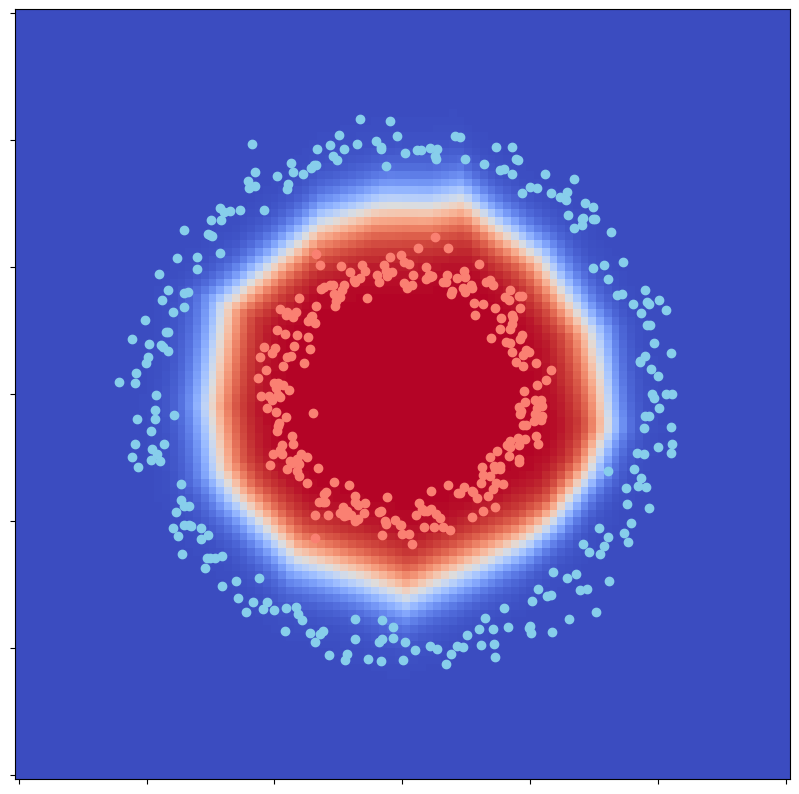

In [ ]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from matplotlib import animation
from IPython.core.display import display, HTML

iX = tf.placeholder('float', shape=[None, X.shape[1]])
iY = tf.placeholder('float', shape=[None])

Ir = 0.1
nn = [2, 16, 8, 1]

#capa 1
W1 = tf.Variable(tf.random_normal([nn[0],nn[1]]), name ='Weights_1')
b1 = tf.Variable(tf.random_normal([nn[1]]), name ='bias_1')
l1 = tf.nn.relu(tf.add(tf.matmul(iX,W1), b1))

#capa 2
W2 = tf.Variable(tf.random_normal([nn[1],nn[2]]), name ='Weights_2')
b2 = tf.Variable(tf.random_normal([nn[2]]), name ='bias_2')
l2 = tf.nn.relu(tf.add(tf.matmul(l1,W2), b2))

#capa 3
W3 = tf.Variable(tf.random_normal([nn[2],nn[3]]), name ='Weights_3')
b3 = tf.Variable(tf.random_normal([nn[3]]), name ='bias_3')

pY =tf.nn.sigmoid(tf.add(tf.matmul(l2,W3),b3))[:,0]

loss = tf.losses.mean_squared_error(pY, iY)

optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.5).minimize(loss)
n_steps = 1000 #numero de ciclos de entrenamiento
iPY = []

with tf.Session() as sess:
  sess.run(tf.global_variables_initializer())
  for i in range(n_steps):
    # Calculate loss and training predictions with training data
    _, _loss, _pY_training =sess.run([optimizer, loss, pY], feed_dict={iX:X, iY:Y})
    if i %25 ==0:
      acc =np.mean(np.round(_pY_training)==Y)
      print('Step', i, '/', n_steps, '- Loss =', _loss, '- Acc =', acc)
      # Calculate predictions for the plotting grid _pX
      _pY_grid = sess.run(pY, feed_dict={iX:_pX})
      iPY.append(_pY_grid)

ims= []
fig = plt.figure(figsize=(10,10))
print("-----Generando animacion-----")

for fr in range(len(iPY)):
  # Now iPY[fr] contains predictions for the 10000 grid points, so reshape is valid
  im =plt.pcolormesh(_x0, _x1, iPY[fr].reshape(res, res), cmap="coolwarm", animated=True)
  plt.scatter(X[Y == 0,0], X[Y == 0,1], c="skyblue")
  plt.scatter(X[Y == 1,0], X[Y == 1,1], c="Salmon") # Changed to Y == 1
  plt.tick_params(labelbottom=False, labelleft=False)
  ims.append([im])

ani= animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)
HTML(ani.to_html5_video())

In [ ]:
import tensorflow as tf
import tensorflow.keras as kr

from IPython.core.display import display, HTML

lr = 0.01  # learning rate
nn = [2, 16, 8, 1]  # número de neuronas por capa.

# Creamos el objeto que contendrá a nuestra red neuronal, como
# secuencia de capas.
model = kr.Sequential()

# Añadimos la capa 1
l1 = model.add(kr.layers.Dense(nn[1], activation='relu'))

# Añadimos la capa 2
l2 = model.add(kr.layers.Dense(nn[2], activation='relu'))

# Añadimos la capa 3
l3 = model.add(kr.layers.Dense(nn[3], activation='sigmoid'))

# Compilamos el modelo, definiendo la función de coste y el optimizador.
model.compile(loss='mse', optimizer=kr.optimizers.SGD(lr=0.05), metrics=['acc'])

# Y entrenamos al modelo. Los callbacks
model.fit(X, Y, epochs=100)

ValueError: Argument(s) not recognized: {'lr': 0.05}

In [ ]:
import sklearn as sk
import sklearn.neural_network

from IPython.core.display import dislay, HTML

lr=0.01
nn=[2, 16, 8, 1]
clf =sk.neural_network.MLPRegressor(solve='sgd',
                                    learning_rate_init=lr,
                                    hiddem_layer_sizes=tuple(nn[1:]),
                                    verbose=True,
                                    n_iter_no_change=1000,
                                    batch_size = 64)

clf.fit(X, Y)


ImportError: cannot import name 'dislay' from 'IPython.core.display' (/usr/local/lib/python3.12/dist-packages/IPython/core/display.py)